# Tornado Casualty Prediction Model

Predict whether a tornado event will result in human casualties using start location and distance to the nearest radar as features.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, mean_squared_error, mean_absolute_error,
                              r2_score, roc_curve)
from sklearn.inspection import permutation_importance

## Load Tornado Event Data

Reads the already-cleaned `tornadoes_all_humanimpact.csv` from `data/processed`.
It already includes casualty/damage columns and a precomputed EF scale, so no
raw StormEvents parsing or EF-scale extraction is needed here.

In [2]:
PROCESSED = "../data/processed"
RAW = "../data/raw"

df = pd.read_csv(f"{PROCESSED}/tornadoes_all_humanimpact.csv", index_col=0)
df = df.rename(columns={"YEAR": "year", "MONTH": "month", "TOR_F_SCALE": "ef_scale"})

# -1 marks unrated events (EFU in the source data); treat as missing
df.loc[df["ef_scale"] == -1, "ef_scale"] = np.nan

print(f"Tornado events loaded : {len(df):,}")
print(f"Year range            : {df['year'].min()}-{df['year'].max()}")
print(f"Columns               : {list(df.columns)}")
print(f"\nMissing / unknown ef_scale : {df['ef_scale'].isna().sum():,}")
df.head()

Tornado events loaded : 30,251
Year range            : 1990-2025
Columns               : ['year', 'month', 'RADAR_DIST', 'BEGIN_LAT', 'BEGIN_LON', 'ef_scale', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'RADAR_COV']

Missing / unknown ef_scale : 1,277


,year,month,RADAR_DIST,BEGIN_LAT,BEGIN_LON,ef_scale,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,RADAR_COV
0,1990,6,91.212078,44.37,-92.63,1.0,0,0,0,0,25000.0,0.0,True
1,1990,5,25.755913,42.08,-71.40,0.0,0,0,0,0,2500.0,0.0,True
2,1990,6,86.672025,41.10,-98.47,0.0,0,0,0,0,2500.0,0.0,True
3,1990,6,115.815290,41.52,-97.73,0.0,0,0,0,0,25000.0,0.0,True
4,1990,6,127.396500,40.25,-100.75,4.0,0,0,0,0,2500000.0,0.0,True


## Load NEXRAD radar locations

In [3]:
with open(RAW + "/nexrad_sites.json") as f:
    nexrad_data = json.load(f)

conus, non_conus = [], []

for feat in nexrad_data["features"]:
    props = feat["properties"]
    lon, lat = feat["geometry"]["coordinates"][:2]
    rda = props.get("rda") or {}
    rda_props = rda.get("properties") or {}
    record = {
        "id":     props.get("id"),
        "name":   props.get("name"),
        "lat":    lat,
        "lon":    lon,
        "status": rda_props.get("status"),
        "operability": rda_props.get("operabilityStatus"),
    }
    if -130 <= lon <= -60 and 20 <= lat <= 55:
        conus.append(record)
    else:
        non_conus.append(record)

radar_df = pd.DataFrame(conus)
print(f"CONUS radars included : {len(radar_df)}")
print(f"Non-CONUS excluded    : {len(non_conus)}")

if non_conus:
    print("\nExcluded (outside CONUS bounds):")
    for r in non_conus:
        print(f"  {r['id']:6s}  {r['name']:<25s}  lat={r['lat']:.2f}  lon={r['lon']:.2f}")

radar_df.head()

CONUS radars included : 143
Non-CONUS excluded    : 16

Excluded (outside CONUS bounds):
  PGUA    Andersen AFB               lat=13.46  lon=144.81
  PACG    Sitka                      lat=56.85  lon=-135.53
  PAHG    Kenai                      lat=60.73  lon=-151.35
  PHWA    South Shore                lat=19.09  lon=-155.57
  PHKM    Kamuela/Kohala Apt         lat=20.13  lon=-155.78
  PAEC    Nome                       lat=64.51  lon=-165.29
  RKSG    Camp Humphreys             lat=37.21  lon=127.29
  PHMO    Molokai                    lat=21.13  lon=-157.18
  PAKC    King Salmon                lat=58.68  lon=-156.63
  PAIH    Middleton Island           lat=59.46  lon=-146.30
  TJUA    San Juan                   lat=18.12  lon=-66.08
  PAPD    Fairbanks Faa              lat=65.04  lon=-147.50
  PABC    Bethel                     lat=60.79  lon=-161.88
  RODN    Kadena AB                  lat=26.30  lon=127.91
  PHKI    South Kauai                lat=21.89  lon=-159.55
  RKJK    Kunsa

,id,name,lat,lon,status,operability
0,KOKX,Brookhaven,40.86552,-72.86392,Operate,RDA - On-line
1,KJAX,Jacksonville,30.48463,-81.70190,Operate,RDA - On-line
2,KHGX,Houston,29.47194,-95.07888,Operate,RDA - On-line
3,KRLX,"Charleston,WV",38.31110,-81.72277,Operate,RDA - On-line
4,KAMA,Amarillo,35.23333,-101.70927,Operate,RDA - On-line


## Distance to nearest radars

In [4]:
# Effective distance out from a radar is about 100 km. 
# Any further and tornadoes are more difficult to detect.

# Blind spot within ~18.5 km of a radar.


def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = np.deg2rad(lat1), np.deg2rad(lon1), np.deg2rad(lat2), np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

radar_lats = radar_df["lat"].values   # shape (143,)
radar_lons = radar_df["lon"].values

event_lats = df["BEGIN_LAT"].values[:, None]  # shape (N, 1) for broadcasting
event_lons = df["BEGIN_LON"].values[:, None]

# Pairwise distance matrix: shape (N, 143)
dist_matrix = haversine(event_lats, event_lons, radar_lats, radar_lons)

# 3 nearest distances per event, sorted ascending
nearest3 = np.sort(np.partition(dist_matrix, 3, axis=1)[:, :3], axis=1)

df["nearest_radar_km_1"] = nearest3[:, 0]
df["nearest_radar_km_2"] = nearest3[:, 1]
df["nearest_radar_km_3"] = nearest3[:, 2]

# Blindspot: True if no radar is in the usable detection range [18.5, 100] km
in_range = (dist_matrix >= 18.5) & (dist_matrix <= 100)   # shape (N, 143)
df["in_blindspot"] = ~in_range.any(axis=1)

print(f"Columns added: nearest_radar_km_1, nearest_radar_km_2, nearest_radar_km_3, in_blindspot")
print(f"\nBlindspot events : {df['in_blindspot'].sum():,}  ({df['in_blindspot'].mean()*100:.1f}%)")
print(f"\nSummary stats (km):")
print(df[["nearest_radar_km_1", "nearest_radar_km_2", "nearest_radar_km_3"]].describe().round(1))
df.head()


Columns added: nearest_radar_km_1, nearest_radar_km_2, nearest_radar_km_3, in_blindspot

Blindspot events : 11,372  (37.6%)

Summary stats (km):
       nearest_radar_km_1  nearest_radar_km_2  nearest_radar_km_3
count             30251.0             30251.0             30251.0
mean                 86.1               163.1               210.0
std                  85.3                85.4                88.1
min                   0.1                44.5                85.9
25%                  52.6               131.8               177.2
50%                  81.5               159.0               204.1
75%                 112.0               187.7               234.1
max                4106.9              4384.0              4549.4


,year,month,RADAR_DIST,BEGIN_LAT,BEGIN_LON,ef_scale,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,RADAR_COV,nearest_radar_km_1,nearest_radar_km_2,nearest_radar_km_3,in_blindspot
0,1990,6,91.212078,44.37,-92.63,1.0,0,0,0,0,25000.0,0.0,True,91.212078,130.020424,276.251685,False
1,1990,5,25.755913,42.08,-71.40,0.0,0,0,0,0,2500.0,0.0,True,25.755913,181.962987,221.846763,False
2,1990,6,86.672025,41.10,-98.47,0.0,0,0,0,0,2500.0,0.0,True,86.672025,177.628491,199.591939,False
3,1990,6,115.815290,41.52,-97.73,0.0,0,0,0,0,25000.0,0.0,True,115.815290,146.142861,241.111927,True
4,1990,6,127.396500,40.25,-100.75,4.0,0,0,0,0,2500000.0,0.0,True,127.396500,190.471547,195.929716,True


## Human Impact Score

In [5]:
df["human_impact"] = (
    (df["DEATHS_DIRECT"].fillna(0) + df["DEATHS_INDIRECT"].fillna(0)) * 10 +
    df["INJURIES_DIRECT"].fillna(0) + df["INJURIES_INDIRECT"].fillna(0)
)

df["has_casualties"] = df["human_impact"] > 0

print(f"Events with casualties    : {df['has_casualties'].sum():,}  ({df['has_casualties'].mean()*100:.2f}%)")
print(f"Events without casualties : {(~df['has_casualties']).sum():,}  ({(~df['has_casualties']).mean()*100:.2f}%)")
print(f"\nhuman_impact summary:")
print(df["human_impact"].describe().round(1))
df.head()

Events with casualties    : 2,300  (7.60%)
Events without casualties : 27,951  (92.40%)

human_impact summary:
count    30251.0
mean         1.3
std         21.8
min          0.0
25%          0.0
50%          0.0
75%          0.0
max       2760.0
Name: human_impact, dtype: float64


,year,month,RADAR_DIST,BEGIN_LAT,BEGIN_LON,ef_scale,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,RADAR_COV,nearest_radar_km_1,nearest_radar_km_2,nearest_radar_km_3,in_blindspot,human_impact,has_casualties
0,1990,6,91.212078,44.37,-92.63,1.0,0,0,0,0,25000.0,0.0,True,91.212078,130.020424,276.251685,False,0,False
1,1990,5,25.755913,42.08,-71.40,0.0,0,0,0,0,2500.0,0.0,True,25.755913,181.962987,221.846763,False,0,False
2,1990,6,86.672025,41.10,-98.47,0.0,0,0,0,0,2500.0,0.0,True,86.672025,177.628491,199.591939,False,0,False
3,1990,6,115.815290,41.52,-97.73,0.0,0,0,0,0,25000.0,0.0,True,115.815290,146.142861,241.111927,True,0,False
4,1990,6,127.396500,40.25,-100.75,4.0,0,0,0,0,2500000.0,0.0,True,127.396500,190.471547,195.929716,True,0,False


## Model Dataset & Train/Test Split

In [11]:
# Include all tornado events — casualty and non-casualty alike.
# log1p(0) = 0 for zero-impact events, so the model learns to predict
# both the zero-casualty majority and the high-impact tail.

FEATURES = [
    "BEGIN_LAT", "BEGIN_LON",
    "nearest_radar_km_1", "nearest_radar_km_2", "nearest_radar_km_3",
    "ef_scale",
    "in_blindspot",
    "month",
]

# ef_scale isn't an active model feature (commented out above), but the
# residualized-model baseline further down needs it complete
df_model = df.dropna(subset=FEATURES + ["ef_scale", "human_impact"]).copy()

# Stratification key: year × has_casualties so every split has a
# proportional mix of casualty and non-casualty events.
df_model["strat_key"] = (df_model["year"].astype(str) + "_" +
                          df_model["human_impact"].gt(0).astype(str))

# Drop rare strata (< 2 samples) that cannot be stratified
strat_counts = df_model["strat_key"].value_counts()
rare = strat_counts[strat_counts < 2].index
if len(rare):
    n_drop = df_model["strat_key"].isin(rare).sum()
    print(f"Dropping {n_drop} events in rare year×casualty strata: {list(rare)}")
    df_model = df_model[~df_model["strat_key"].isin(rare)].copy()

n_cas   = df_model["human_impact"].gt(0).sum()
n_nocas = df_model["human_impact"].eq(0).sum()
print(f"Total events with complete features : {len(df_model):,}")
print(f"  With casualties  : {n_cas:,}  ({n_cas/len(df_model)*100:.1f}%)")
print(f"  No casualties    : {n_nocas:,}  ({n_nocas/len(df_model)*100:.1f}%)")
print()

y_all     = np.log1p(df_model["human_impact"].values)
strat_arr = df_model["strat_key"].to_numpy()

idx_all = np.arange(len(df_model))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.20, random_state=42, stratify=strat_arr,
)
y_train = y_all[idx_train]
y_test  = y_all[idx_test]

print(f"Training : {len(idx_train):,} events  (80%)")
print(f"Test     : {len(idx_test):,} events  (20%)  ← held out")


Total events with complete features : 28,974
  With casualties  : 2,300  (7.9%)
  No casualties    : 26,674  (92.1%)

Training : 23,179 events  (80%)
Test     : 5,795 events  (20%)  ← held out


Train subset : 18,543 events
Validation   : 4,636 events

Validation metrics (log₁ₚ scale):
  RMSE    : 0.4605
  R²     : 0.3182
  ROC AUC : 0.8527


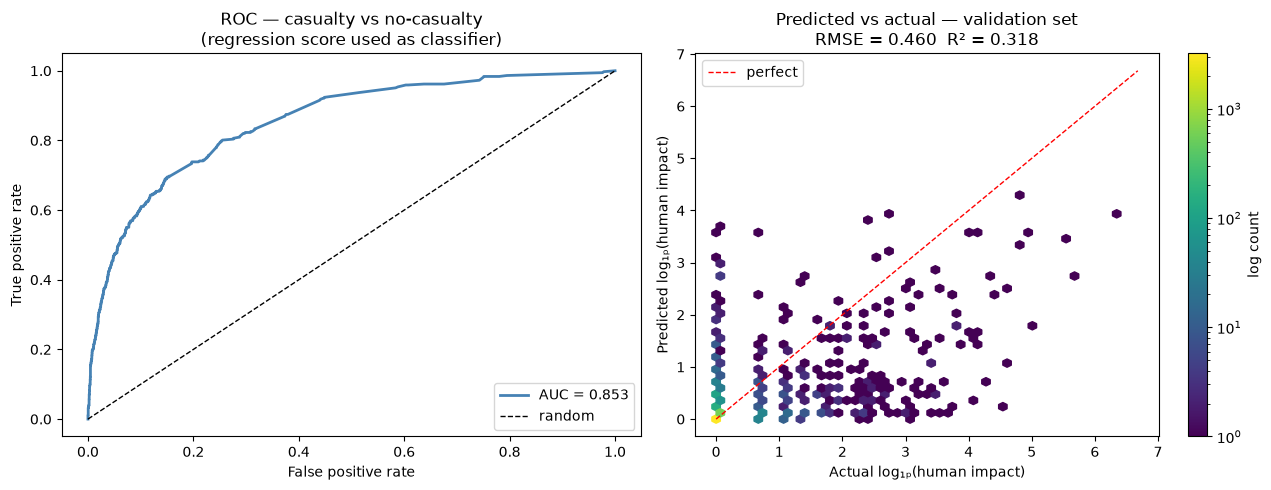

In [12]:
# Further split training data 80/20 into train / validation.
# Stratify by year × casualty to maintain proportional representation.
# Test set (idx_test) remains untouched.

strat_train_arr = df_model["strat_key"].to_numpy()[idx_train]
idx_tr, idx_val = train_test_split(
    np.arange(len(idx_train)), test_size=0.20, random_state=42, stratify=strat_train_arr,
)

X_all = df_model[FEATURES].astype(float).to_numpy()
X_tr  = X_all[idx_train][idx_tr]
X_val = X_all[idx_train][idx_val]
y_tr  = y_train[idx_tr]
y_val = y_train[idx_val]

print(f"Train subset : {len(y_tr):,} events")
print(f"Validation   : {len(y_val):,} events")
print()

reg_pipe = Pipeline([("clf", HistGradientBoostingRegressor(max_iter=300, random_state=42))])
reg_pipe.fit(X_tr, y_tr)

y_val_pred = reg_pipe.predict(X_val)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val   = r2_score(y_val, y_val_pred)

# ROC: use regression score to discriminate casualty vs non-casualty events
y_val_binary = (y_val > 0).astype(int)
auc_val      = roc_auc_score(y_val_binary, y_val_pred)
fpr, tpr, _  = roc_curve(y_val_binary, y_val_pred)

print(f"Validation metrics (log\u2081\u209a scale):")
print(f"  RMSE    : {rmse_val:.4f}")
print(f"  R\u00b2     : {r2_val:.4f}")
print(f"  ROC AUC : {auc_val:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
ax1.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc_val:.3f}")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax1.set_xlabel("False positive rate")
ax1.set_ylabel("True positive rate")
ax1.set_title("ROC \u2014 casualty vs no-casualty\n(regression score used as classifier)")
ax1.legend(loc="lower right")

# Hexbin: predicted vs actual in log1p scale
lim = max(y_val.max(), y_val_pred.max()) * 1.05
hb  = ax2.hexbin(y_val, y_val_pred, gridsize=50, bins="log",
                  cmap="viridis", extent=(0, lim, 0, lim))
ax2.plot([0, lim], [0, lim], "r--", lw=1, label="perfect")
ax2.set_xlabel("Actual log\u2081\u209a(human impact)")
ax2.set_ylabel("Predicted log\u2081\u209a(human impact)")
ax2.set_title(f"Predicted vs actual \u2014 validation set\n"
              f"RMSE = {rmse_val:.3f}  R\u00b2 = {r2_val:.3f}")
plt.colorbar(hb, ax=ax2, label="log count")
ax2.legend()

plt.tight_layout()
plt.show()


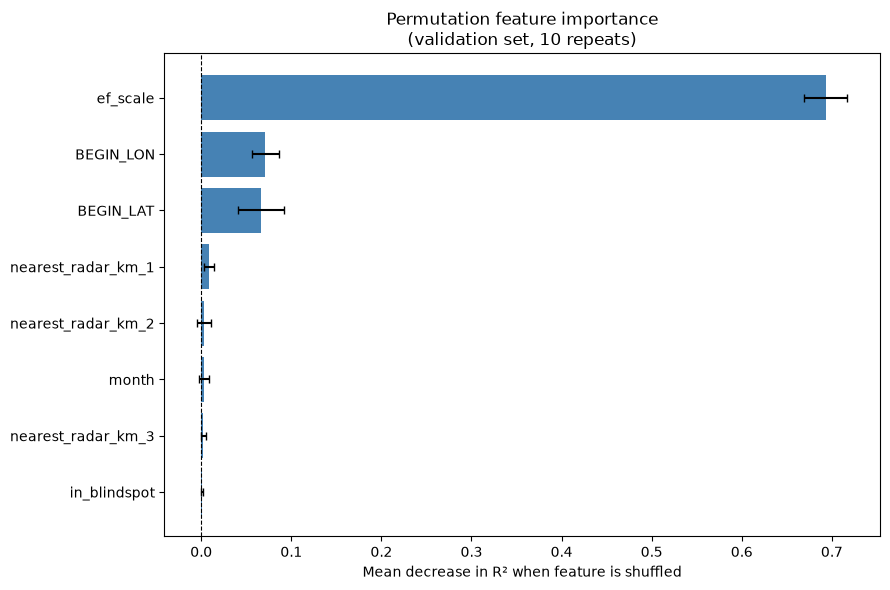

Permutation importance (sorted high → low):
  Feature                     Mean ΔR²     ± std
  ----------------------------------------------
  ef_scale                      0.6933    0.0240
  BEGIN_LON                     0.0712    0.0147
  BEGIN_LAT                     0.0663    0.0257
  nearest_radar_km_1            0.0084    0.0054
  nearest_radar_km_2            0.0029    0.0077
  month                         0.0026    0.0056
  nearest_radar_km_3            0.0023    0.0028
  in_blindspot                  0.0006    0.0014


In [13]:
# Feature importance via permutation: shuffle each feature on the validation set
# and measure the drop in R². HistGradientBoostingRegressor does not expose
# built-in MDI importances, so permutation importance is the standard approach.

feat_names = FEATURES

perm = permutation_importance(
    reg_pipe, X_val, y_val,
    n_repeats=10, random_state=42, scoring="r2", n_jobs=-1,
)

order = np.argsort(perm.importances_mean)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh([feat_names[i] for i in order], perm.importances_mean[order],
                xerr=perm.importances_std[order], color="steelblue", capsize=3)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Mean decrease in R\u00b2 when feature is shuffled")
ax.set_title("Permutation feature importance\n(validation set, 10 repeats)")
plt.tight_layout()
plt.show()

print("Permutation importance (sorted high \u2192 low):")
print(f"  {'Feature':<25} {'Mean \u0394R\u00b2':>10}  {'\u00b1 std':>8}")
print("  " + "-" * 46)
for i in reversed(order):
    print(f"  {feat_names[i]:<25} {perm.importances_mean[i]:>10.4f}  {perm.importances_std[i]:>8.4f}")


Baseline (EF only) — training:
  intercept : -0.0775
  coef      : 0.3361  (per EF unit in log₁ₚ scale)

Residual stats (validation set):
  mean  : -0.0157  (near zero = good baseline fit)
  std   : 0.5000

Residual model R² on validation set : 0.0091
(Original model R² with ef_scale   : 0.3182)



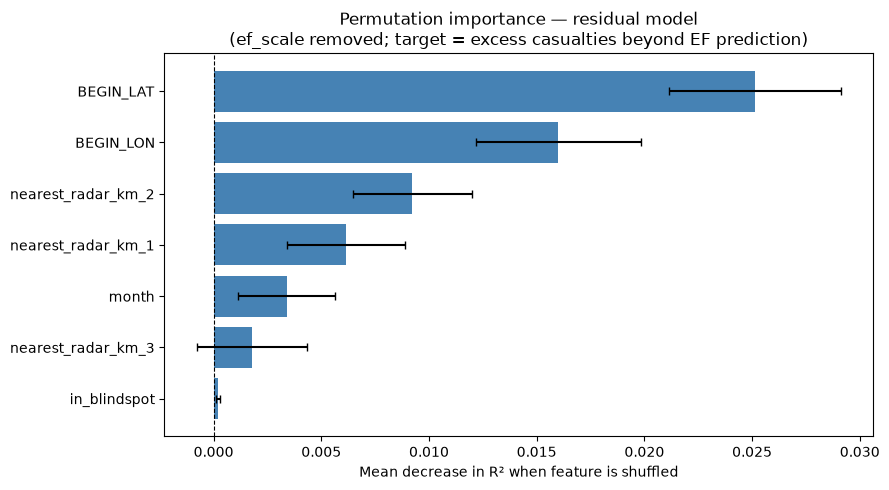

Permutation importance on residuals (sorted high → low):
  Feature                     Mean ΔR²     ± std
  ----------------------------------------------
  BEGIN_LAT                     0.0251    0.0040
  BEGIN_LON                     0.0160    0.0038
  nearest_radar_km_2            0.0092    0.0028
  nearest_radar_km_1            0.0062    0.0027
  month                         0.0034    0.0023
  nearest_radar_km_3            0.0018    0.0026
  in_blindspot                  0.0002    0.0001


In [14]:
# Approach A: residualized casualties.
# Step 1 — fit a baseline that captures only the EF scale → casualty relationship
#           (trained on X_tr so no leakage into validation).
# Step 2 — subtract baseline predictions to get residuals: what EF scale alone
#           cannot explain.
# Step 3 — model those residuals with the remaining features (no ef_scale),
#           so radar distance, location, and population must do the work.
# Step 4 — permutation importance to see whether radar features now matter.

from sklearn.linear_model import LinearRegression

FEATURES_RESID = [f for f in FEATURES if f != "ef_scale"]

# --- Step 1: baseline (EF scale only, fit on training subset) ---
X_ef_tr  = df_model[["ef_scale"]].astype(float).to_numpy()[idx_train][idx_tr]
X_ef_val = df_model[["ef_scale"]].astype(float).to_numpy()[idx_train][idx_val]

baseline = LinearRegression()
baseline.fit(X_ef_tr, y_tr)

print("Baseline (EF only) — training:")
print(f"  intercept : {baseline.intercept_:.4f}")
print(f"  coef      : {baseline.coef_[0]:.4f}  (per EF unit in log\u2081\u209a scale)")
print()

# --- Step 2: residuals ---
y_resid_tr  = y_tr  - baseline.predict(X_ef_tr)
y_resid_val = y_val - baseline.predict(X_ef_val)

print(f"Residual stats (validation set):")
print(f"  mean  : {y_resid_val.mean():.4f}  (near zero = good baseline fit)")
print(f"  std   : {y_resid_val.std():.4f}")
print()

# --- Step 3: model residuals with non-EF features ---
X_resid_tr  = df_model[FEATURES_RESID].astype(float).to_numpy()[idx_train][idx_tr]
X_resid_val = df_model[FEATURES_RESID].astype(float).to_numpy()[idx_train][idx_val]

resid_pipe = Pipeline([("clf", HistGradientBoostingRegressor(max_iter=300, random_state=42))])
resid_pipe.fit(X_resid_tr, y_resid_tr)

from sklearn.metrics import r2_score as _r2
r2_resid = _r2(y_resid_val, resid_pipe.predict(X_resid_val))
print(f"Residual model R\u00b2 on validation set : {r2_resid:.4f}")
print(f"(Original model R\u00b2 with ef_scale   : {r2_val:.4f})")
print()

# --- Step 4: permutation importance on residual model ---
perm_resid = permutation_importance(
    resid_pipe, X_resid_val, y_resid_val,
    n_repeats=10, random_state=42, scoring="r2", n_jobs=-1,
)

order = np.argsort(perm_resid.importances_mean)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([FEATURES_RESID[i] for i in order], perm_resid.importances_mean[order],
         xerr=perm_resid.importances_std[order], color="steelblue", capsize=3)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Mean decrease in R\u00b2 when feature is shuffled")
ax.set_title("Permutation importance — residual model\n"
             "(ef_scale removed; target = excess casualties beyond EF prediction)")
plt.tight_layout()
plt.show()

print("Permutation importance on residuals (sorted high \u2192 low):")
print(f"  {'Feature':<25} {'Mean \u0394R\u00b2':>10}  {'\u00b1 std':>8}")
print("  " + "-" * 46)
for i in reversed(order):
    print(f"  {FEATURES_RESID[i]:<25} {perm_resid.importances_mean[i]:>10.4f}  "
          f"{perm_resid.importances_std[i]:>8.4f}")


In [15]:
# Hyperparameter search — expanded ranges based on previous run hitting boundaries.
# Uses year × casualty stratified 3-fold CV on the training subset only.

param_dist = {
    "clf__max_iter":          [100, 200, 300, 500, 1000],
    "clf__learning_rate":     [0.1, 0.2, 0.3, 0.5],
    "clf__max_leaf_nodes":    [4, 8, 15, 31],
    "clf__min_samples_leaf":  [50, 100, 200, 500],
    "clf__l2_regularization": [0.1, 1.0, 5.0, 10.0, 50.0],
}

strat_tr_arr = df_model["strat_key"].to_numpy()[idx_train][idx_tr]
cv_strat     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_splits_tr = list(cv_strat.split(X_tr, strat_tr_arr))

search = RandomizedSearchCV(
    Pipeline([("clf", HistGradientBoostingRegressor(random_state=42))]),
    param_distributions=param_dist,
    n_iter=40,
    cv=cv_splits_tr,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
)
search.fit(X_tr, y_tr)

print("\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('clf__', ''):<22} {v}")
print(f"\nBest CV RMSE (log\u2081\u209a) : {-search.best_score_:.4f}")

y_val_pred_best = search.best_estimator_.predict(X_val)
rmse_best = np.sqrt(mean_squared_error(y_val, y_val_pred_best))
r2_best   = r2_score(y_val, y_val_pred_best)
auc_best  = roc_auc_score((y_val > 0).astype(int), y_val_pred_best)

print(f"\n{'Metric':<12} {'Baseline':>10} {'Best params':>12}")
print("-" * 36)
print(f"{'RMSE':<12} {rmse_val:>10.4f} {rmse_best:>12.4f}")
print(f"{'R\u00b2':<12} {r2_val:>10.4f} {r2_best:>12.4f}")
print(f"{'ROC AUC':<12} {auc_val:>10.4f} {auc_best:>12.4f}")


Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best parameters:
  min_samples_leaf       50
  max_leaf_nodes         4
  max_iter               200
  learning_rate          0.2
  l2_regularization      1.0

Best CV RMSE (log₁ₚ) : 0.4739

Metric         Baseline  Best params
------------------------------------
RMSE             0.4605       0.4590
R²               0.3182       0.3225
ROC AUC          0.8527       0.8498
